# Setup

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
import sys
from pathlib import Path

def find_repo_root(start: Path, marker=".git") -> Path:
    for parent in [start, *start.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not find repo root from {start}")

repo_base = find_repo_root(Path.cwd())
# repo_base
tools_path = repo_base / "tools"
sys.path.append(str(tools_path))

In [3]:
from battle import *

def pull_by_id(num):
    return Battle(f'./../../data/replays/gen9-randombattle/gen9randombattle-{num}.json')

log_dir = repo_base / f"replays/gen9-randombattle/"
logs = Path('./../../data/replays/gen9-randombattle/')

In [4]:
rows = []

stat_names = ["hp","atk","def","spa","spd","spe"]

for file in logs.iterdir():
    if (file.is_file() and (file.name[0]!='.')) :
        try : 
            battle = Battle(file)
        except UnicodeDecodeError as e : 
            print(f"Could not handle {file.name} : {e}")
            continue
        if not battle.custom_ruleQ:
            to_add = { # initial non-team data we may want to train on
                "id": battle.id.removeprefix("gen9randombattle-"),
                "rated": battle.rated,
                "duration": battle.end_time - battle.start_time,
                "p1": battle.p1.name,
                "p2": battle.p2.name,
                "p1_elo" : battle.p1.elo0,
                "p2_elo": battle.p2.elo0,
                "p1_wins" : battle.p1.name == battle.winner.name,
            }

            # team data and stats for each mon
            for i in range(2):
                for j, mon_name in enumerate(battle.teams_full[i].keys()):
                    poke = battle.teams_full[i][mon_name]
                    to_add[f"p{i+1}k{j+1}_id"] = poke["speciesId"]
                    for stat in stat_names:
                        to_add[f"p{i+1}k{j+1}_{stat}"] = poke["stats"][stat]
                    try:
                        for k in range(2):
                            to_add[f"p{i+1}k{j+1}_T{k}"] = poke['types'][k] if (k < len(poke['types'])) else None
                    except KeyError as e:
                        print(f"Error with {poke["speciesId"]} in {battle.id}")
                        continue
            rows.append(to_add)

In [5]:
df = pd.DataFrame(rows)

In [6]:
df.head(15)

,id,rated,duration,p1,p2,p1_elo,p2_elo,p1_wins,p1k1_id,p1k1_hp,...,p2k5_T1,p2k6_id,p2k6_hp,p2k6_atk,p2k6_def,p2k6_spa,p2k6_spd,p2k6_spe,p2k6_T0,p2k6_T1
0,2631906096,True,598,sufideu,saberclaw,1135,1140,False,quaquaval,264,...,Fairy,klefki,233,139,201,183,194,174,Steel,Fairy
1,2631763570,False,167,PineappleCats,L4V,1959,1949,False,greninja,246,...,None,toxtricity,257,165,162,234,162,170,Electric,Poison
2,2631369343,True,275,Chicken347,cococem,1999,2068,True,munkidori,269,...,None,electrodehisui,246,92,172,189,189,311,Electric,Grass
3,2631529004,False,123,WhatEver2102,Duck Cop,1999,1982,True,sinistcha,254,...,None,terapagos,265,105,175,145,175,137,Normal,None
4,2631993792,False,301,monomythic,OverthereStair,2120,2062,False,ambipom,263,...,None,trevenant,296,247,186,166,197,150,Ghost,Grass
5,2631629401,False,116,Elite 4 Waally,jsjsiis,1958,1920,False,sudowoodo,284,...,None,probopass,257,105,316,188,325,125,Rock,Steel
6,2631479578,False,112,gamergray23,TheOldTimers,1928,1927,False,appletun,352,...,Dragon,regice,284,93,226,226,402,138,Ice,None
7,2631439736,False,448,Mr Brightside,indias last hope,2115,2259,False,clodsire,343,...,None,reuniclus,337,119,182,270,200,103,Psychic,None
8,2631771408,False,287,Illuminating_Fate,medo6037,2170,2177,True,sandyshocks,267,...,Flying,barraskewda,231,246,144,144,128,267,Water,None
9,2631528750,True,326,Emily Montes,Elite 4 Waally,1907,1937,True,staraptor,263,...,Rock,cobalion,277,149,253,190,161,219,Steel,Fighting


In [12]:
for i in range(2):
    for j in range(6):
        new_col_name = f"p{i+1}k{j+1}_atkM"
        old_col_names = [f"p{i+1}k{j+1}_atk", f"p{i+1}k{j+1}_spa"]
        matches[new_col_name] = matches[old_col_names].max(axis=1)
        matches = matches.drop(columns=old_col_names)

# EDA

In [9]:
import ydata_profiling
from ydata_profiling import ProfileReport

In [3]:
!{sys.executable} -m pip install --upgrade setuptools

In [ ]:
profile = ProfileReport(df2, title="pokemonEDA")
profile.to_file("report.html")

# Decision Tree

In [7]:
# pokemon data
df_num = df.select_dtypes(include='number')
y_win = 1 * df.p1_wins # bool -> {0,1}

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

import numpy as np
from matplotlib import pyplot as plt

# for guided example
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [14]:
clf = DecisionTreeClassifier(max_depth=2, random_state=42)
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [15]:
tree.plot_tree(clf, proportion=True)
plt.show()

AttributeError: 'DecisionTreeClassifier' object has no attribute 'plot_tree'

In [11]:
tree.

np.int64(4)

# Boosts

In [35]:
import pandas as pd


In [34]:
X.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


# SKLEARN EXAMPLES

In [16]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

from sklearn.datasets import load_iris
from sklearn.ensemble import (
    AdaBoostClassifier,
    ExtraTreesClassifier,
    RandomForestClassifier,
)
from sklearn.tree import DecisionTreeClassifier

In [17]:
for pair in ([0, 1], [0, 2], [2, 3]):
    print(pair)

[0, 1]
[0, 2]
[2, 3]


In [25]:
iris.data[:5,:]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [28]:
iris.data[:5,:2]

array([[5.1, 3.5],
       [4.9, 3. ],
       [4.7, 3.2],
       [4.6, 3.1],
       [5. , 3.6]])

In [39]:
# Parameters
n_classes = 3
n_estimators = 30
cmap = plt.cm.RdYlBu

# Load data
iris = load_iris()

models = [
    DecisionTreeClassifier(max_depth=2),
    RandomForestClassifier(n_estimators=n_estimators),
    ExtraTreesClassifier(n_estimators=n_estimators),
    AdaBoostClassifier(DecisionTreeClassifier(max_depth=2), n_estimators=n_estimators),
]

# models = [DecisionTreeClassifier(max_depth=2)]

In [ ]:
#42A5F4

DecisionTree with features [0, 1] has a score of 0.7733333333333333
RandomForest with 30 estimators with features [0, 1] has a score of 0.9266666666666666
ExtraTrees with 30 estimators with features [0, 1] has a score of 0.9266666666666666
AdaBoost with 30 estimators with features [0, 1] has a score of 0.7933333333333333
DecisionTree with features [0, 2] has a score of 0.9533333333333334
RandomForest with 30 estimators with features [0, 2] has a score of 0.9933333333333333
ExtraTrees with 30 estimators with features [0, 2] has a score of 0.9933333333333333
AdaBoost with 30 estimators with features [0, 2] has a score of 0.9933333333333333
DecisionTree with features [2, 3] has a score of 0.96
RandomForest with 30 estimators with features [2, 3] has a score of 0.9933333333333333
ExtraTrees with 30 estimators with features [2, 3] has a score of 0.9933333333333333
AdaBoost with 30 estimators with features [2, 3] has a score of 0.9933333333333333


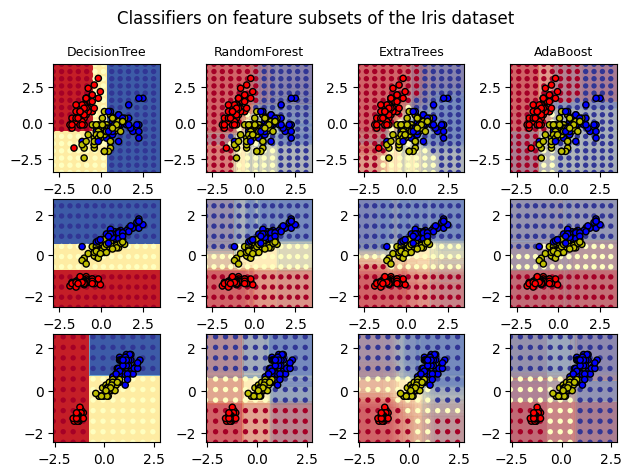

In [45]:
plot_step = 0.02  # fine step width for decision surface contours
plot_step_coarser = 0.5  # step widths for coarse classifier guesses
RANDOM_SEED = 13  # fix the seed on each iteration


plot_idx = 1
for pair in ([0, 1], [0, 2], [2, 3]):
    for model in models:
        # We only take the two corresponding features
        X = iris.data[:, pair] # shape (?,2)
        y = iris.target

        # Shuffle
        idx = np.arange(X.shape[0])
        np.random.seed(RANDOM_SEED)
        np.random.shuffle(idx)
        X = X[idx] 
        y = y[idx]

        # Standardize
        mean = X.mean(axis=0)
        std = X.std(axis=0)
        X = (X - mean) / std

        # =======================================
        # Train
        model.fit(X, y)
        scores = model.score(X, y)
        # =======================================
        
        # Create a title for each column and the console by using str() and
        # slicing away useless parts of the string
        model_title = str(type(model)).split(".")[-1][:-2][: -len("Classifier")]
        
        model_details = model_title
        if hasattr(model, "estimators_"):
            model_details += " with {} estimators".format(len(model.estimators_))
        print(model_details + " with features", pair, "has a score of", scores)
        
        # =======================================
        plt.subplot(3, 4, plot_idx)
        if plot_idx <= len(models):
            # Add a title at the top of each column
            plt.title(model_title, fontsize=9)
        # =======================================
        
        # Now plot the decision boundary using a fine mesh as input to a
        # filled contour plot
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(
            np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step)
        )

        # Plot either a single DecisionTreeClassifier or alpha blend the
        # decision surfaces of the ensemble of classifiers
        if isinstance(model, DecisionTreeClassifier):
            Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
            Z = Z.reshape(xx.shape)
            cs = plt.contourf(xx, yy, Z, cmap=cmap)
        else:
            # Choose alpha blend level with respect to the number
            # of estimators
            # that are in use (noting that AdaBoost can use fewer estimators
            # than its maximum if it achieves a good enough fit early on)
            estimator_alpha = 1.0 / len(model.estimators_)
            for tree in model.estimators_:
                Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
                Z = Z.reshape(xx.shape)
                cs = plt.contourf(xx, yy, Z, alpha=estimator_alpha, cmap=cmap)

        # Build a coarser grid to plot a set of ensemble classifications
        # to show how these are different to what we see in the decision
        # surfaces. These points are regularly space and do not have a
        # black outline
        xx_coarser, yy_coarser = np.meshgrid(
            np.arange(x_min, x_max, plot_step_coarser),
            np.arange(y_min, y_max, plot_step_coarser),
        )
        
        Z_points_coarser = model.predict(
            np.c_[xx_coarser.ravel(), yy_coarser.ravel()]
        ).reshape(xx_coarser.shape)
        
        cs_points = plt.scatter(
            xx_coarser,
            yy_coarser,
            s=15,
            c=Z_points_coarser,
            cmap=cmap,
            edgecolors="none",
        )

        # Plot the training points, these are clustered together and have a
        # black outline
        plt.scatter(
            X[:, 0],
            X[:, 1],
            c=y,
            cmap=ListedColormap(["r", "y", "b"]),
            edgecolor="k",
            s=20,
        )
        plot_idx += 1  # move on to the next plot in sequence

plt.suptitle("Classifiers on feature subsets of the Iris dataset", fontsize=12)
plt.axis("tight")
plt.tight_layout(h_pad=0.2, w_pad=0.2, pad=1.0)
plt.show()